In [1]:
import geopandas as gpd
import pandas as pd
import os, json, xmltodict, math
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib
import load_data_new_type as ld
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap
%matplotlib inline

In [2]:
shapefile_path = os.path.join(os.getcwd(), "shapefile")

#cwbxml
with open(os.getcwd()+"\\xml\\4-18-2.xml", encoding="utf-8") as xml_file:
    data_dict = xmltodict.parse(xml_file.read())
    cwb_data = json.loads(json.dumps(data_dict, ensure_ascii=False).encode("utf-8").decode())
    Identifier = cwb_data["earthquake"]["identifier"]
    Schemaver = cwb_data["earthquake"]["schemaVer"]
    Language = cwb_data["earthquake"]["language"]
    Sendername = cwb_data["earthquake"]["senderName"]
    Senttime = cwb_data["earthquake"]["sent"]
    Status = cwb_data["earthquake"]["status"]
    Msgtype = cwb_data["earthquake"]["msgType"]
    MsgNo = cwb_data["earthquake"]["msgNo"]
    Description = cwb_data["earthquake"]["description"]
    Origintime = cwb_data["earthquake"]["originTime"]
    Lat = float(cwb_data["earthquake"]["epicenter"]["epicenterLat"]["#text"])
    Lon = float(cwb_data["earthquake"]["epicenter"]["epicenterLon"]["#text"])
    Depth = cwb_data["earthquake"]["depth"]["#text"]
    Magnitude = cwb_data["earthquake"]["magnitude"]["magnitudeValue"]
    pgaAdj = cwb_data["earthquake"]["pgaAdj"]

    cwb_origin_time = datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00").timestamp() 
    replay_start_time = datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00").timestamp() - 3
    print(replay_start_time, cwb_origin_time)
    print(datetime.fromtimestamp(replay_start_time))

1618755277.0 1618755280.0
2021-04-18 22:14:37


In [3]:
town = gpd.read_file(shapefile_path+"\TOWN_MOI_1091016.shp", encoding="utf-8")
county = gpd.read_file(shapefile_path+"\COUNTY_MOI_1090820.shp", encoding="utf-8")
crs = county.crs

# variables #
#data
mqtt_data = "4.18//Alarms_026.json"
site_data = "4.18//Sites_026.json"
trigger_site = []
trigger_cwb = []
calculating_list = []
data_list = []
sp_site = ["S00049"]

frame_rate = 0.1 #10 frame/per second
s_radius = 0.045 
p_radius = 0.055

#zero point
origin_x = 119 
origin_y = 21.8 
delta_x = 3.3 
delta_y = 3.7

t_size = 20 #text size

cbw = 2.3 #county_boundary_width
tbw = 0.5 #town_boundary_width

#eq_data
data = ld.load_data(mqtt_data)
replay_end_time = datetime.strptime(data[-1]["Date"]+" "+data[-1]["Time"], "%Y-%m-%d %H:%M:%S.%f").timestamp() #data.iloc[-1, 0].timestamp()
replay_loop = round((replay_end_time-replay_start_time)/frame_rate)
print(replay_end_time)


#site_data
site_df = ld.load_site(site_data)
site_df["Calculate_Time"] = ""
#print(site_df)

for index, row in site_df.iterrows():
    if row["Site_ID"] in sp_site:
        time_tmp = row["Trigger_Time"] - timedelta(seconds=1)
        site_df.iloc[index, site_df.columns.get_loc("Calculate_Time")] = time_tmp

    else:
        time_tmp = row["Trigger_Time"] - timedelta(seconds=3)
        site_df.iloc[index, site_df.columns.get_loc("Calculate_Time")] = time_tmp
#print(site_df)
site_geo = gpd.GeoDataFrame(site_df, geometry=gpd.points_from_xy(site_df.Site_Lon, site_df.Site_Lat))


#for ind, row in site_geo.iterrows():
    #print(ind,row["Site_ID"])
#Datetime = list(set(site_df.Datetime.tolist()))
#Trigger_Time = list(set(site_df.Trigger_Time.tolist()))
#Datetime.sort()
#Trigger_Time.sort()

#site_times = {
#        "Datetime":Datetime,
#        "Trigger_Time":Trigger_Time
#}



1618755357.613


2021-04-18 22:14:37.100000
2021-04-18 22:14:37.200000
2021-04-18 22:14:37.300000
2021-04-18 22:14:37.400000
2021-04-18 22:14:37.500000
2021-04-18 22:14:37.600000
2021-04-18 22:14:37.700000
2021-04-18 22:14:37.800000
2021-04-18 22:14:37.900000
2021-04-18 22:14:38
2021-04-18 22:14:38.100000
2021-04-18 22:14:38.200000
2021-04-18 22:14:38.300000
2021-04-18 22:14:38.400000
2021-04-18 22:14:38.500000
2021-04-18 22:14:38.600000
2021-04-18 22:14:38.700000
2021-04-18 22:14:38.800000
2021-04-18 22:14:38.900000
2021-04-18 22:14:39
2021-04-18 22:14:39.100000
2021-04-18 22:14:39.200000
2021-04-18 22:14:39.300000
2021-04-18 22:14:39.400000
2021-04-18 22:14:39.500000
2021-04-18 22:14:39.600000
2021-04-18 22:14:39.700000
2021-04-18 22:14:39.800000
2021-04-18 22:14:39.900000
2021-04-18 22:14:40
2021-04-18 22:14:40.100000
------start main loop-------
2021-04-18 22:14:40.100000
2021-04-18 22:14:40.200000
2021-04-18 22:14:40.300000
2021-04-18 22:14:40.400000
2021-04-18 22:14:40.500000
2021-04-18 22:14:40.

2021-04-18 22:14:48.800000
2021-04-18 22:14:48.900000
2021-04-18 22:14:49
2021-04-18 22:14:49.100000
2021-04-18 22:14:49.200000
2021-04-18 22:14:49.300000
2021-04-18 22:14:49.400000
2021-04-18 22:14:49.500000
2021-04-18 22:14:49.600000
  Site_ID  Site_Lat  Site_Lon  Site_Level      PGAx            Trigger_Time  \
5  S00021    23.837  120.9025         3.0  22.05535 2021-04-18 22:14:52.561   

               Calculate_Time                    geometry  
5  2021-04-18 22:14:49.561000  POINT (120.90250 23.83700)  
2021-04-18 22:14:49.700000
2021-04-18 22:14:49.800000
2021-04-18 22:14:49.900000
2021-04-18 22:14:50
2021-04-18 22:14:50.100000
2021-04-18 22:14:50.200000
  Site_ID  Site_Lat  Site_Lon  Site_Level      PGAx            Trigger_Time  \
6  S00117    24.438   121.381         4.0  46.61836 2021-04-18 22:14:53.129   

               Calculate_Time                    geometry  
6  2021-04-18 22:14:50.129000  POINT (121.38100 24.43800)  
2021-04-18 22:14:50.300000
2021-04-18 22:14:50.4000

2021-04-18 22:14:55.800000
2021-04-18 22:14:55.900000
plot data
    TOWNID  TOWNCODE COUNTYNAME TOWNNAME            TOWNENG COUNTYID  \
30     G11  10002110        宜蘭縣      大同鄉    Datong Township        G   
157    G12  10002120        宜蘭縣      南澳鄉    Nan'ao Township        G   
38     J14  10004120        新竹縣      尖石鄉   Jianshi Township        J   
77     M02  10008020        南投縣      埔里鎮      Puli Township        M   
79     M04  10008040        南投縣      竹山鎮   Zhushan Township        M   
80     M05  10008050        南投縣      集集鎮      Jiji Township        M   
82     M07  10008070        南投縣      鹿谷鄉      Lugu Township        M   
84     M09  10008090        南投縣      魚池鄉     Yuchi Township        M   
86     M11  10008110        南投縣      水里鄉    Shuili Township        M   
88     M13  10008130        南投縣      仁愛鄉    Ren'ai Township        M   
342    U01  10015010        花蓮縣      花蓮市       Hualien City        U   
343    U04  10015040        花蓮縣      新城鄉  Xincheng Township        U   


2021-04-18 22:14:57.200000
   Site_ID  Site_Lat  Site_Lon  Site_Level      PGAx            Trigger_Time  \
15  S00075    23.767   120.527         4.0  40.33462 2021-04-18 22:15:00.125   

                Calculate_Time                    geometry  
15  2021-04-18 22:14:57.125000  POINT (120.52700 23.76700)  
   Site_ID  Site_Lat  Site_Lon  Site_Level      PGAx            Trigger_Time  \
16  S00074   24.6562   120.956         4.0  38.27485 2021-04-18 22:15:00.191   

                Calculate_Time                    geometry  
16  2021-04-18 22:14:57.191000  POINT (120.95600 24.65620)  
2021-04-18 22:14:57.300000
2021-04-18 22:14:57.400000
2021-04-18 22:14:57.500000
2021-04-18 22:14:57.600000
2021-04-18 22:14:57.700000
2021-04-18 22:14:57.800000
2021-04-18 22:14:57.900000
2021-04-18 22:14:58
2021-04-18 22:14:58.100000
2021-04-18 22:14:58.200000
   Site_ID  Site_Lat  Site_Lon  Site_Level      PGAx            Trigger_Time  \
17  S00078     24.38   120.638         4.0  61.55024 2021-04-18 

2021-04-18 22:14:59.200000
2021-04-18 22:14:59.300000
2021-04-18 22:14:59.400000
   Site_ID  Site_Lat  Site_Lon  Site_Level      PGAx            Trigger_Time  \
21  S00068   23.6869  120.3483         3.0  23.46292 2021-04-18 22:15:02.383   

                Calculate_Time                    geometry  
21  2021-04-18 22:14:59.383000  POINT (120.34830 23.68690)  
2021-04-18 22:14:59.500000
   Site_ID  Site_Lat  Site_Lon  Site_Level      PGAx            Trigger_Time  \
22  S00096    24.769  120.9785         4.0  42.57632 2021-04-18 22:15:02.458   

                Calculate_Time                    geometry  
22  2021-04-18 22:14:59.458000  POINT (120.97850 24.76900)  
2021-04-18 22:14:59.600000
2021-04-18 22:14:59.700000
2021-04-18 22:14:59.800000
2021-04-18 22:14:59.900000
2021-04-18 22:15:00
plot data
    TOWNID  TOWNCODE COUNTYNAME TOWNNAME             TOWNENG COUNTYID  \
30     G11  10002110        宜蘭縣      大同鄉     Datong Township        G   
157    G12  10002120        宜蘭縣      南澳鄉  

...

2021-04-18 22:15:02.200000
plot data
    TOWNID  TOWNCODE COUNTYNAME TOWNNAME            TOWNENG COUNTYID  \
30     G11  10002110        宜蘭縣      大同鄉    Datong Township        G   
157    G12  10002120        宜蘭縣      南澳鄉    Nan'ao Township        G   
31     J02  10004020        新竹縣      竹東鎮   Zhudong Township        J   
33     J03  10004040        新竹縣      關西鎮    Guanxi Township        J   
35     J10  10004070        新竹縣      芎林鄉  Qionglin Township        J   
..     ...       ...        ...      ...                ...      ...   
221    B21  66000210        臺中市      外埔區     Waipu District        B   
260    B22  66000220        臺中市      大安區     Da'an District        B   
223    B29  66000290        臺中市      和平區    Heping District        B   
265    H09  68000090        桃園市      龍潭區   Longtan District        H   
266    H13  68000130        桃園市      復興區    Fuxing District        H   

    COUNTYCODE                                           geometry  Intensity  
30       10002  POL

2021-04-18 22:15:04.500000
2021-04-18 22:15:04.600000
   Site_ID  Site_Lat  Site_Lon  Site_Level      PGAx            Trigger_Time  \
35  S00066   23.2999  120.2574         2.0  2.588907 2021-04-18 22:15:07.557   

                Calculate_Time                    geometry  
35  2021-04-18 22:15:04.557000  POINT (120.25740 23.29990)  
2021-04-18 22:15:04.700000
2021-04-18 22:15:04.800000
2021-04-18 22:15:04.900000
2021-04-18 22:15:05
plot data
    TOWNID  TOWNCODE COUNTYNAME TOWNNAME            TOWNENG COUNTYID  \
30     G11  10002110        宜蘭縣      大同鄉    Datong Township        G   
157    G12  10002120        宜蘭縣      南澳鄉    Nan'ao Township        G   
158    J05  10004010        新竹縣      竹北市        Zhubei City        J   
31     J02  10004020        新竹縣      竹東鎮   Zhudong Township        J   
32     J04  10004030        新竹縣      新埔鎮     Xinpu Township        J   
..     ...       ...        ...      ...                ...      ...   
223    B29  66000290        臺中市      和平區    Hepi

2021-04-18 22:15:14.100000
2021-04-18 22:15:14.200000
2021-04-18 22:15:14.300000
2021-04-18 22:15:14.400000
2021-04-18 22:15:14.500000
   Site_ID  Site_Lat  Site_Lon  Site_Level      PGAx            Trigger_Time  \
42  S00062   22.6747  120.2888         0.0  0.577971 2021-04-18 22:15:17.493   

                Calculate_Time                    geometry  
42  2021-04-18 22:15:14.493000  POINT (120.28880 22.67470)  
2021-04-18 22:15:14.600000
2021-04-18 22:15:14.700000
2021-04-18 22:15:14.800000
2021-04-18 22:15:14.900000
2021-04-18 22:15:15
2021-04-18 22:15:15.100000
2021-04-18 22:15:15.200000
2021-04-18 22:15:15.300000
2021-04-18 22:15:15.400000
2021-04-18 22:15:15.500000
2021-04-18 22:15:15.600000
2021-04-18 22:15:15.700000
2021-04-18 22:15:15.800000
2021-04-18 22:15:15.900000
   Site_ID  Site_Lat  Site_Lon  Site_Level      PGAx            Trigger_Time  \
43  S00060   22.6162  120.3835         1.0  1.035861 2021-04-18 22:15:18.808   

                Calculate_Time                    

2021-04-18 22:15:36.100000
2021-04-18 22:15:36.200000
2021-04-18 22:15:36.300000
2021-04-18 22:15:36.400000
2021-04-18 22:15:36.500000
2021-04-18 22:15:36.600000
2021-04-18 22:15:36.700000
2021-04-18 22:15:36.800000
2021-04-18 22:15:36.900000
2021-04-18 22:15:37
2021-04-18 22:15:37.100000
2021-04-18 22:15:37.200000
2021-04-18 22:15:37.300000
2021-04-18 22:15:37.400000
2021-04-18 22:15:37.500000
2021-04-18 22:15:37.600000
2021-04-18 22:15:37.700000
2021-04-18 22:15:37.800000
2021-04-18 22:15:37.900000
2021-04-18 22:15:38
2021-04-18 22:15:38.100000
2021-04-18 22:15:38.200000
2021-04-18 22:15:38.300000
2021-04-18 22:15:38.400000
2021-04-18 22:15:38.500000
2021-04-18 22:15:38.600000
2021-04-18 22:15:38.700000
2021-04-18 22:15:38.800000
2021-04-18 22:15:38.900000
2021-04-18 22:15:39
2021-04-18 22:15:39.100000
2021-04-18 22:15:39.200000
2021-04-18 22:15:39.300000
2021-04-18 22:15:39.400000
2021-04-18 22:15:39.500000
2021-04-18 22:15:39.600000
2021-04-18 22:15:39.700000
2021-04-18 22:15:39.80

2021-04-18 22:15:53.300000
2021-04-18 22:15:53.400000
2021-04-18 22:15:53.500000
2021-04-18 22:15:53.600000
2021-04-18 22:15:53.700000
2021-04-18 22:15:53.800000
2021-04-18 22:15:53.900000
2021-04-18 22:15:54
2021-04-18 22:15:54.100000
2021-04-18 22:15:54.200000
2021-04-18 22:15:54.300000
2021-04-18 22:15:54.400000
2021-04-18 22:15:54.500000
2021-04-18 22:15:54.600000
2021-04-18 22:15:54.700000
2021-04-18 22:15:54.800000
2021-04-18 22:15:54.900000
2021-04-18 22:15:55
2021-04-18 22:15:55.100000
2021-04-18 22:15:55.200000
2021-04-18 22:15:55.300000
2021-04-18 22:15:55.400000
2021-04-18 22:15:55.500000
2021-04-18 22:15:55.600000
2021-04-18 22:15:55.700000
2021-04-18 22:15:55.800000
2021-04-18 22:15:55.900000
2021-04-18 22:15:56
2021-04-18 22:15:56.100000
2021-04-18 22:15:56.200000
2021-04-18 22:15:56.300000
2021-04-18 22:15:56.400000
2021-04-18 22:15:56.500000
2021-04-18 22:15:56.600000
2021-04-18 22:15:56.700000
2021-04-18 22:15:56.800000
2021-04-18 22:15:56.900000
2021-04-18 22:15:57
20

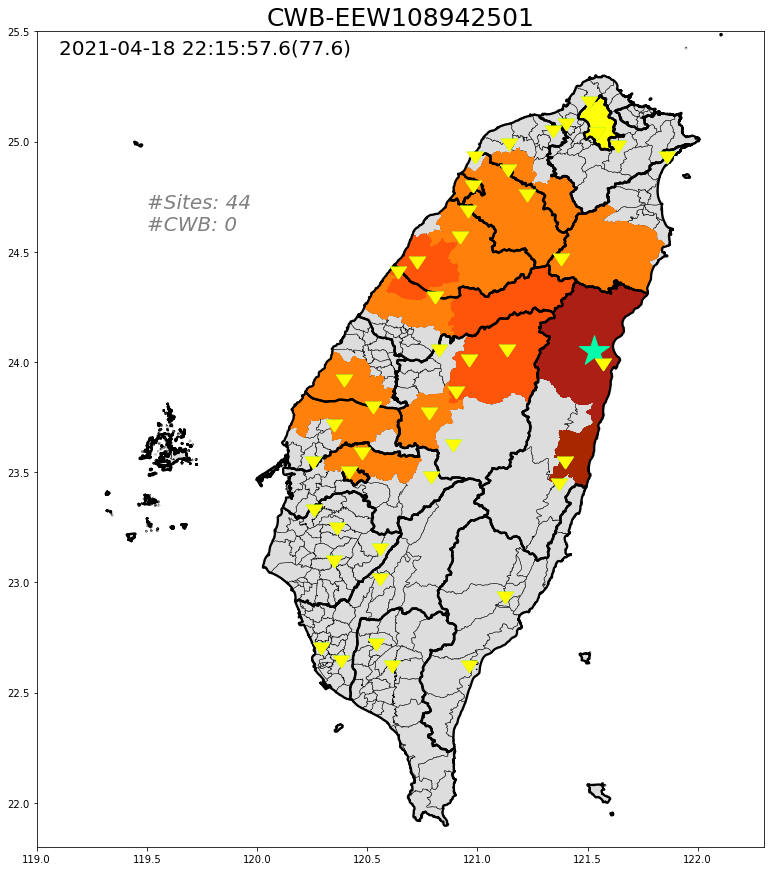

In [4]:
#plotting eq data
color_map = [
        '#C4FBE2',
        '#26FF0B',
        '#FFFE0B',
        '#FF810B',
        '#FF550B',
        '#AC1F14',
        '#A92700',
        '#983476',
        '#BB20D9'
]
cLevel = [1, 2, 3, 4, 5, 5.5, 6, 6.5, 7]
cmap, norm = matplotlib.colors.from_levels_and_colors(cLevel, color_map, extend="max")

#norm = matplotlib.colors.BoundaryNorm(cLevel,9)
#norm = matplotlib.colors.Normalize(vmin=1, vmax=7, clip=True)
#cm = matplotlib.colors.ListedColormap(color_map)
#cmap1 = LinearSegmentedColormap.from_list("my_colormap", color_map, N=9, gamma=1.0)


#map init
f, axes = plt.subplots(figsize=(15,15))
axes.set_title(Identifier, fontsize=25)
county.boundary.plot(ax=axes, color="black", edgecolor="black",linewidth=cbw, zorder=2)  #draw counties
l1 = town.plot(ax=axes, color="#dddddd", edgecolor="black", linewidth=tbw, zorder=1)     #draw towns
    
#set pic location
minx, miny, maxx, maxy = (origin_x, origin_y, origin_x + delta_x, origin_y + delta_y)
l1.set_xlim(minx, maxx)
l1.set_ylim(miny, maxy)
#event_time = (datetime.strptime(Origintime.replace("T", " "), "%Y-%m-%d %H:%M:%S+08:00"))
replay_time = datetime.fromtimestamp(replay_start_time)

#TextBoxes
axes_time = axes.text(minx+0.1, maxy-0.1, replay_time, size=t_size)
axes_site_count = axes.text(119.5, 24.7, "#Sites: "+str(len(trigger_site)), size=t_size, style='italic', c="gray")
axes_cwb_count = axes.text(119.5, 24.6, "#CWB: "+str(len(trigger_cwb)), size=t_size, style='italic', c="gray")


#plotting eq_center
eq_center = pd.DataFrame({"Name":"eq_center", "Latitude":[Lat], "Longitude":[Lon]})
eq_center = gpd.GeoDataFrame(eq_center, geometry=gpd.points_from_xy(eq_center.Longitude, eq_center.Latitude))
eq_center.plot(ax=axes, color="#00ffaa", marker="*", markersize=1000, zorder=3)

#before_event_process
while replay_time <= datetime.fromtimestamp(cwb_origin_time):
    replay_time += timedelta(seconds=frame_rate)
    print(replay_time)
    replay_time_str = replay_time.strftime("%Y-%m-%d %H_%M_%S.%f")[:-5]
    axes.texts[-3].set_text((replay_time_str.replace("_",":")+ "({})".format(round(replay_time.timestamp() - cwb_origin_time ,2))))
    axes.plot()
    axes.figure.savefig(replay_time_str+".png")
    
data_index = 0

print("------start main loop-------")
for time in range(replay_loop):
    
    #Main loop使用到的變數
    AreaDetail = []
    draw_area = gpd.GeoDataFrame()
    replay_time_str = replay_time.strftime("%Y-%m-%d %H_%M_%S.%f")[:-5]
    print(replay_time)
    
    #回放時間超過則停止
    if replay_time.timestamp() >= replay_end_time:
        break
    
    #P波、S波的初始化
    p_circle = plt.Circle((Lon, Lat), radius=p_radius, color="red", lw=2.0, ls="--", fill=False)
    axes.add_patch(p_circle)
    s_circle = plt.Circle((Lon, Lat), radius=s_radius, color="red", lw=2.0, fill=False)
    axes.add_patch(s_circle)
    
    #繪製計算中站台
    calculating_site = site_geo.loc[replay_time >= site_geo["Calculate_Time"]]
    for index, row in site_geo.iterrows():
        
        #若播放時間大於站台計算時間
        if replay_time >= row["Calculate_Time"]:
            if row["Site_ID"] not in calculating_list:
                calculating_list.append(row["Site_ID"])                
                calculating_site_plot = site_geo.iloc[[index], :]
                print(calculating_site_plot)
                calculating_site_plot.plot(ax=axes, color="#3BFF3A", edgecolor="black", marker=7, markersize=250, zorder=3)
                #axes.figure.savefig(str(time)+"C"+".png")

                
        #若播放時間大於站台觸發時間
        if replay_time >= row["Trigger_Time"] and row["Site_ID"] in calculating_list:
            if row["Site_ID"] not in trigger_site:
                trigger_site.append(row["Site_ID"])
                trigger_site_plot = site_geo.iloc[[index], :]
                trigger_site_plot.plot(ax=axes, color="#FFFB00", edgecolor="black", marker=7, markersize=250, zorder=3)
                axes.texts[-2].set_text("#Sites: "+str(len(trigger_site)))
        
    #若播放時間大於現地預警時間
    if replay_time >= datetime.strptime(data[data_index]["Date"]+" "+data[data_index]["Time"], "%Y-%m-%d %H:%M:%S.%f"):
        print("plot data")
        
        Areas = data[data_index]["Areas"]
        for Area in Areas:
            AreaDetail.append((Area["AreaCode"], Area["Source"], Area["PGAx"], ld.pga_to_level(float(Area["PGAx"]))))
            if Area["Source"] not in trigger_cwb and Area["Source"].startswith("CWB"):
                trigger_cwb.append(Area["Source"])
                axes.texts[-1].set_text("#CWB: "+str(len(trigger_cwb)))
                
        Area_df = pd.DataFrame(AreaDetail, columns=["AreaCode", "Source", "PGA", "Intensity"])
        Area_df = Area_df.sort_values(by=["AreaCode", "PGA"])
        for i in range(len(Area_df)):
            draw = town[town.TOWNCODE == Area_df.loc[i, "AreaCode"]]
            draw = draw.assign(Intensity = Area_df.loc[i, "Intensity"])
            draw_area = draw_area.append(draw)
        
        print(draw_area)
        draw_area.plot("Intensity", ax=axes, cmap=cmap, norm=norm)
        
        data_index += 1
        
    #P波、S波及字串處理
    ##1.P波、S波的累加
    p_radius += 0.005
    s_radius += 0.0025
    ##2.時間字串處理
    axes.texts[-3].set_text((replay_time_str.replace("_",":")+ "({})".format(round(replay_time.timestamp() - cwb_origin_time ,2))))
    
    axes.plot()
    axes.figure.savefig(replay_time_str + ".png")
    
    
    #儲存後的動作
    
    p_circle.remove()
    s_circle.remove()
    replay_time += timedelta(seconds=frame_rate)

In [5]:
import imageio

impath = os.path.join(os.getcwd(), "2")
print(impath)
filenames = os.listdir(impath)
img = []
for filename in filenames:
    #print(filename)
    img.append(imageio.imread(os.path.join(impath, filename)))
print("張數:",len(img))
imageio.mimsave(os.path.join(impath, "4_18_new.gif"), img)

C:\GIT\eqreplay\2
張數: 806
